In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as srn
import sklearn as skl

In [53]:
#Carregamento dos dados e analise exploratória dos dados
#Carregando os dados
titanic_gender = pd.read_csv("/content/drive/MyDrive/gender_submission.csv")
titanic_train = pd.read_csv("/content/drive/MyDrive/train.csv", sep = ",")
test_df = pd.read_csv("/content/drive/MyDrive/test.csv", sep = ",")
passengerId = test_df['PassengerId']
#Visualizando os dados
#titanic_gender.head()
test_df.head()
#titanic_train.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [ ]:
titanic_train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
#Estatistica descritiva do dataset
titanic_train.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [ ]:
#Verificando a integridade dos dados e valores ausentes
titanic_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
#Contabilizando os NA's por colunas
na_colunas = titanic_train.isna().sum()
print(na_colunas)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
#Limpando os dados faltantes
titanic_train['Age'].fillna(titanic_train['Age'].median(), inplace=True)
titanic_train['Embarked'].fillna(titanic_train['Embarked'].mode()[0], inplace=True)

#Verificando os NA's por colunas novamente
print(titanic_train.isna().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64


/tmp/ipykernel_856/161078740.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_train['Age'].fillna(titanic_train['Age'].median(), inplace=True)
/tmp/ipykernel_856/161078740.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

In [ ]:
#Transformando a variavel Cabin em 0 e 1 (Tem cabine, não tem cabine)
#"A variável Cabin possui grande quantidade de valores ausentes.
#Em vez de imputar valores artificiais, foi criada uma nova variável binária indicando a presença ou ausência de cabine, capturando indiretamente o status socioeconômico dos passageiros."

# Check if 'Cabin' column exists before processing
if 'Cabin' in titanic_train.columns:
    titanic_train['HasCabin'] = titanic_train['Cabin'].notnull().astype(int)
    titanic_train.drop('Cabin', axis = 1, inplace = True)
else:
    print("Column 'Cabin' not found. It might have been processed and dropped already.")

titanic_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,HasCabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0


[]

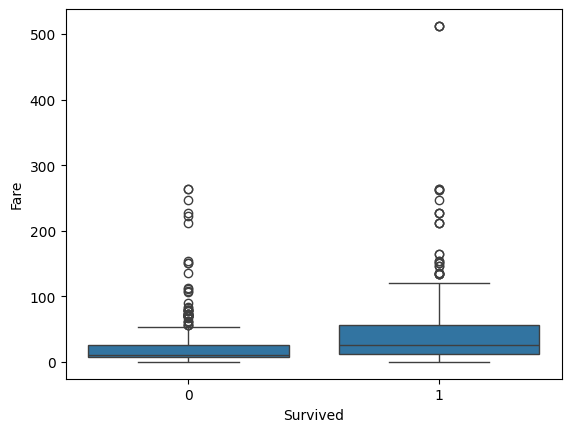

In [ ]:

#Analisando a variável Fare
titanic_train['Fare'].describe()
srn.boxplot(x = 'Survived', y = 'Fare', data = titanic_train)
plt.plot()

#A pergunta a ser respondida é: Quem pagou mais, sobreviveu mais?
#Podemos observar pelo gráfico que existe sim uma relação entre quem pagou mais e a taxa de sobrevivencia.
#Observa-se que passageiros que pagaram tarifas mais elevadas apresentaram maior taxa de sobrevivência,
#indicando uma forte relação entre status socioeconômico e acesso a recursos de evacuação.
#Conclui-se então que pessoas que pagaram mais (1° classe), tiveram mais chances de sobrevivência.



In [ ]:
#Aplicando uma tranformação logaritma em fare, para remover a distribuição assimétrica dos valores
titanic_train['FareLog'] = np.log1p(titanic_train['Fare'])

#Criando uma feature mais preciso de pagamento por pessoa considerando sua familia
titanic_train['FamilySize'] = titanic_train['SibSp'] + titanic_train['Parch'] + 1

titanic_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
 11  HasCabin     891 non-null    int64  
 12  FareLog      891 non-null    float64
 13  FamilySize   891 non-null    int64  
dtypes: float64(3), int64(7), object(4)
memory usage: 97.6+ KB


In [ ]:
titanic_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,HasCabin,FareLog,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0,2.110213,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1,4.280593,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,2.188856,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1,3.990834,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0,2.202765,1


In [ ]:
#Tratando os valores faltantes em Fare, FareLog e FamilySize
titanic_train['Fare'].fillna(titanic_train['Fare'].median(), inplace=True)
titanic_train['FareLog'].fillna(titanic_train['FareLog'].median(), inplace=True)
titanic_train['FamilySize'].fillna(titanic_train['FamilySize'].median(), inplace=True)

titanic_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
 11  HasCabin     891 non-null    int64  
 12  FareLog      891 non-null    float64
 13  FamilySize   891 non-null    int64  
dtypes: float64(3), int64(7), object(4)
memory usage: 97.6+ KB


/tmp/ipykernel_856/4193504229.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_train['Fare'].fillna(titanic_train['Fare'].median(), inplace=True)
/tmp/ipykernel_856/4193504229.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(val

In [ ]:
#Tratamento das variáveis categóricas
#Variavel sex para 0 ou 1 (male: 0; female: 1)
titanic_train['Sex'] = titanic_train['Sex'].map({'male': 0, 'female': 1})

#Variavel Embarked para categórica nominal
titanic_train = pd.get_dummies(titanic_train, columns = ['Embarked'], drop_first = True)

titanic_train.head()
#

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,HasCabin,FareLog,FamilySize,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0,2.110213,2,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,1,4.280593,2,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0,2.188856,1,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,1,3.990834,2,False,True
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,0,2.202765,1,False,True


In [ ]:
#Removendo colunas desnecessárias para o modelo
titanic_train.drop(['PassengerId', 'Name', 'Ticket'], axis = 1, inplace = True)
titanic_train.head()

#Justificativa para a remoção
#PassengerId: Identificador
#Name: Texto irrelevante
#Ticket: Alta cardinalidade

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,HasCabin,FareLog,FamilySize,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,0,2.110213,2,False,True
1,1,1,1,38.0,1,0,71.2833,1,4.280593,2,False,False
2,1,3,1,26.0,0,0,7.9250,0,2.188856,1,False,True
3,1,1,1,35.0,1,0,53.1000,1,3.990834,2,False,True
4,0,3,0,35.0,0,0,8.0500,0,2.202765,1,False,True


In [ ]:
#Tratando a varíavel Pclass para dummies
titanic_train = pd.get_dummies(titanic_train, columns = ['Pclass'], drop_first = True)
titanic_train.head()
#

,Survived,Sex,Age,SibSp,Parch,Fare,HasCabin,FareLog,FamilySize,Embarked_Q,Embarked_S,Pclass_2,Pclass_3
0,0,0,22.0,1,0,7.2500,0,2.110213,2,False,True,False,True
1,1,1,38.0,1,0,71.2833,1,4.280593,2,False,False,False,False
2,1,1,26.0,0,0,7.9250,0,2.188856,1,False,True,False,True
3,1,1,35.0,1,0,53.1000,1,3.990834,2,False,True,False,False
4,0,0,35.0,0,0,8.0500,0,2.202765,1,False,True,False,True


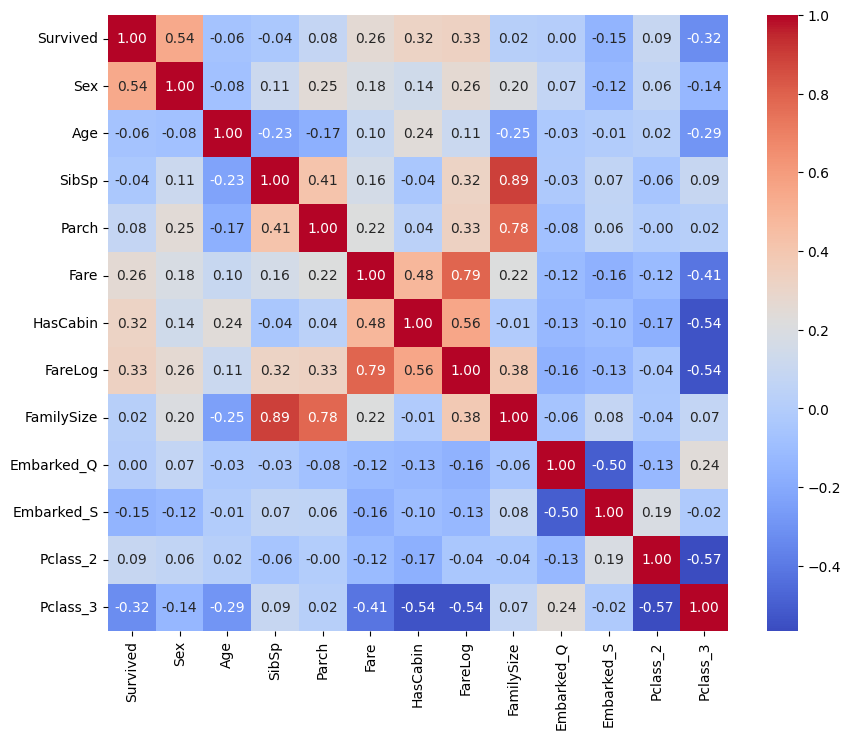

In [ ]:
#Matriz de correlação
plt.figure(figsize=(10,8))
srn.heatmap(titanic_train.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

Pela matriz de correlação, podemos observar as seguites correlações com a variável "Suvived":


*   Sex (0.54): A variável que possui a maior correlação. Condiz com a realidade do acidente, pois a correlação é positiva (mulheres sobreviveram mais). *"women and children first"* ;
*   FareLog (0.33) e Fare (0.26): Pessoas que pagaram mais, sobreviveram mais. Indica status social;
* HasCabin (0.32): Quem tinha cabine registrada teve uma maior chance de sobrevivência (passageiros mais ricos, melhores localizações);
* Pclass_3 (-0.32): Correlação negativa forte. Indica que pessoas da terceira classe tiveram menor chances de sobrevivência;

Pode-se analisar algumas outras correlações. Por exemplo, *FamilySize x SibSp* (0.89) e *FamilySize x Parch* (0.78). Isso indica uma redundância, devido a criação da variável FamilySize. Logo, *SibSp* e *Parch* podem ser retirados do dataset.

Outra correlação, que podemos utilizar para diminuir o dataframe, é *FrameLog x Frame* (0.79). É uma alta correlação devido ao fato de que são informações iguais. A decisão é manter apenas o FrameLog, pois evita dispersão dos dados e naõ atrapalha o modelho.

É possível observar que quanto menor foi a classe de um viajante do titanic, menor era sua chance de sobrevivência. Podemos observar a partir da correlação *Pclass_3 x FareLog* (-0.54).

Além disso, o que chega a ser interessante, é que a correlação *HasCabin x Pclass_3* (-0.54) indica que as pessoas da terceira classe raramente não tinham cabine registradas.

Portanto, podemos concluir que a análise de correlação evidenciou que o sexo do passageiro é o principal fator associado à sobrevivência, seguido por variáveis relacionadas ao status socioeconômico, como tarifa e classe. Também foram identificadas redundâncias entre variáveis derivadas, levando à remoção de atributos como SibSp e Parch em favor de FamilySize.


In [ ]:
#Removendo SibSp e Parch
titanic_train.drop(['SibSp', 'Parch'], axis=1, inplace=True)

In [ ]:
#Modelagem do problema
#Utilizando primeiro Regressão logistica

#Preparando os dados
titanic_train.drop('Fare', axis = 1, inplace = True)
X = titanic_train.drop('Survived', axis = 1)
y = titanic_train['Survived']

#Train/Test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

#Modelo de regressão logística
#Normalização
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Treinamento do modelo
#Treinar
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter = 1000)
log_model.fit(X_train_scaled, y_train)

#Avaliação do modelo
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_pred_log = log_model.predict(X_test_scaled)

#Avaliar
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

#

Logistic Regression
Accuracy: 0.8044692737430168
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



In [ ]:
#Random Florest
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state = 42)
rf_model.fit(X_train, y_train)

#Avaliação do modelo
y_pred_rf = rf_model.predict(X_test)

#Avaliar
print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
#

Random Forest
Accuracy: 0.8268156424581006
              precision    recall  f1-score   support

           0       0.84      0.87      0.85       105
           1       0.80      0.77      0.79        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



Comparação entre modelos

A partir da comparação geral, o modelo Random Forest apresentou desempenho superior à Regressão Logística, o que pode ser observado pela métrica de acurácia:

* Random Forest: 0.827
* Regressão Logística: 0.804

No entanto, a análise não deve se limitar apenas à acurácia. Observando a classe 1 (sobreviventes), o Random Forest obteve um recall de 0.77, enquanto a Regressão Logística apresentou 0.73. Isso indica que o Random Forest é mais eficaz na identificação de passageiros que sobreviveram.

Esse comportamento pode ser explicado pela natureza dos modelos. O Random Forest é capaz de capturar relações não lineares e interações complexas entre variáveis, enquanto a Regressão Logística assume uma relação mais linear, sendo, portanto, mais limitada nesse contexto.

Essa interpretação é reforçada pela análise da matriz de correlação, que indicou a ausência de relações lineares fortes entre as variáveis, mas evidenciou a importância de combinações entre elas.

Para a classe 0 (não sobreviventes), ambos os modelos apresentaram bom desempenho, com recall de:

* Regressão Logística: 0.86
* Random Forest: 0.87

Por fim, conclui-se que o Random Forest apresentou melhor desempenho geral, especialmente na identificação de sobreviventes, enquanto a Regressão Logística, apesar de ligeiramente inferior, oferece maior interpretabilidade, sendo útil para compreensão do impacto das variáveis no modelo.

Dessa forma, a escolha do modelo depende do objetivo: interpretabilidade (Regressão Logística) ou desempenho preditivo (Random Forest).

In [ ]:
#Importancia das variaveis
importances = rf_model.feature_importances_
feat_names = X.columns

feat_imp = pd.Series(importances, index=feat_names)
feat_imp.sort_values(ascending=False)

,0
Sex,0.270926
FareLog,0.248760
Age,0.247988
FamilySize,0.074527
Pclass_3,0.057416
HasCabin,0.047298
Embarked_S,0.024776
Pclass_2,0.018962
Embarked_Q,0.009348


In [ ]:
#Interpretar coeficientes (Logistic Regression)
coef = pd.Series(log_model.coef_[0], index=X.columns)
coef.sort_values()

,0
FamilySize,-0.513908
Age,-0.372941
Embarked_S,-0.225739
Pclass_3,-0.210197
Embarked_Q,-0.051829
Pclass_2,0.268298
FareLog,0.384790
HasCabin,0.505911
Sex,1.271315


Importância das variáveis e interpretação dos coeficientes

A análise de importância das variáveis, obtida a partir do modelo Random Forest, indicou que o sexo do passageiro (Sex) é o fator mais relevante para a previsão de sobrevivência, apresentando a maior contribuição para o modelo. Em seguida, destacam-se as variáveis FareLog e Age, ambas com importâncias muito próximas, o que sugere que tanto o valor pago pela passagem quanto a idade exercem influência significativa na sobrevivência.

Um ponto interessante é que, embora a variável idade tenha apresentado baixa correlação linear com a variável alvo na análise exploratória, ela se mostrou altamente relevante no modelo. Isso indica a presença de relações não lineares, que são capturadas de forma mais eficiente por algoritmos como o Random Forest.

Outras variáveis, como FamilySize, Pclass_3 e HasCabin, também contribuem para o modelo, ainda que com menor impacto. De modo geral, observa-se que variáveis relacionadas ao perfil socioeconômico dos passageiros (como tarifa e classe) continuam sendo importantes para explicar a sobrevivência.

No caso da Regressão Logística, a interpretação dos coeficientes permite compreender o impacto direto de cada variável na probabilidade de sobrevivência.

A variável Sex apresenta o maior coeficiente positivo, indicando que ser do sexo feminino aumenta significativamente a probabilidade de sobrevivência. Esse resultado está alinhado com o contexto histórico do desastre, em que mulheres tiveram prioridade durante a evacuação.

As variáveis HasCabin e FareLog também apresentam coeficientes positivos relevantes, sugerindo que passageiros com cabine registrada e que pagaram tarifas mais altas possuem maior chance de sobreviver. Esses fatores podem ser interpretados como indicadores de status socioeconômico.

Por outro lado, variáveis como Age e FamilySize apresentam coeficientes negativos, indicando que passageiros mais velhos e aqueles que viajavam com famílias maiores tendem a ter menor probabilidade de sobrevivência. No caso do tamanho da família, uma possível explicação é a maior dificuldade de evacuação em grupo.

Além disso, a variável Pclass_3 apresenta impacto negativo, reforçando que passageiros da terceira classe estavam em desvantagem, enquanto Pclass_2 apresenta efeito positivo moderado quando comparada à categoria de referência.

Por fim, as variáveis relacionadas ao porto de embarque (Embarked) apresentaram baixo impacto no modelo, indicando influência limitada na sobrevivência.

De forma geral, os resultados obtidos são consistentes entre os modelos e reforçam que a sobrevivência no Titanic esteve fortemente associada a fatores como sexo, condição socioeconômica e características individuais dos passageiros, além de evidenciar a importância de considerar tanto relações lineares quanto não lineares na modelagem.

In [54]:
#Criando o arquivo de teste para submissão
test_df['Age'].fillna(test_df['Age'].median(), inplace=True)

test_df['Embarked'].fillna(test_df['Embarked'].mode()[0], inplace=True)

if 'Cabin' in test_df.columns:
    test_df['HasCabin'] = test_df['Cabin'].notnull().astype(int)
    test_df.drop('Cabin', axis = 1, inplace = True)
else:
    print("Column 'Cabin' not found. It might have been processed and dropped already.")

    #Aplicando uma tranformação logaritma em fare, para remover a distribuição assimétrica dos valores
test_df['FareLog'] = np.log1p(test_df['Fare'])

#Criando uma feature mais preciso de pagamento por pessoa considerando sua familia
test_df['FamilySize'] = test_df['SibSp'] + test_df['Parch'] + 1

#Tratando os valores faltantes em Fare, FareLog e FamilySize
test_df['Fare'].fillna(test_df['Fare'].median(), inplace=True)
test_df['FareLog'].fillna(test_df['FareLog'].median(), inplace=True)
test_df['FamilySize'].fillna(test_df['FamilySize'].median(), inplace=True)

#Tratamento das variáveis categóricas
#Variavel sex para 0 ou 1 (male: 0; female: 1)
test_df['Sex'] = test_df['Sex'].map({'male': 0, 'female': 1})

#Variavel Embarked para categórica nominal
test_df = pd.get_dummies(test_df, columns = ['Embarked'], drop_first = True)

# Save PassengerId before dropping it
#passenger_ids = test_df['PassengerId']

#Removendo colunas desnecessárias para o modelo
test_df.drop(['PassengerId', 'Name', 'Ticket', 'Fare'], axis = 1, inplace = True)

#Tratando a varíavel Pclass para dummies
test_df = pd.get_dummies(test_df, columns = ['Pclass'], drop_first = True)



#Garantir mesmas colunas do treino
test_df = test_df.reindex(columns=X.columns, fill_value=0)

#Fazer predições
predictions = rf_model.predict(test_df)

#Criar arquivo de submissão
submission = pd.DataFrame({
    "PassengerId": passengerId,
    "Survived": predictions
})

submission.to_csv("submission.csv", index=False)

/tmp/ipykernel_856/429658948.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df['Age'].fillna(test_df['Age'].median(), inplace=True)
/tmp/ipykernel_856/429658948.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

In [55]:
from google.colab import files
files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>